> **Documento storico (v0.9).** Questo notebook documenta un passo intermedio della validazione del
> Caso C ed è conservato per tracciabilità. I numeri validi e la sintesi aggiornata sono in
> `notebooks/05_validazione_caso_C.ipynb` e in `docs/resoconto.md`. Il notebook non viene
> rieseguito: i percorsi relativi (`../outputs`, `../scripts`) si riferiscono alla sua posizione
> originale in `notebooks/`, e alcuni pkl citati sono stati sovrascritti da versioni successive.

# 05 — Checklist di validazione sul Caso C

> **Aggiornamento v0.10 (2026-09-26).** I numeri di questo notebook sono quelli della v0.9. Le
> correzioni (kernel sferico, raggio della calotta, stadio 1 iterato) sono spiegate nel notebook
> `06_correzioni_caso_C.ipynb`; la checklist rifatta con le correzioni, e il confronto con le
> tabelle qui sotto, è nel notebook `07_checklist_caso_C_v2.ipynb`.

Il notebook 04 mostra una sola realizzazione. Per sapere se la ricostruzione è **calibrata**
servono molte ripetizioni con verità nota. Qui si applica la checklist di validazione, nell'ordine:
bias → risoluzione → pull → coverage → contrazione ≈ $1/\sqrt N$ → robustezza al prior.

**Setup.** Per ogni esperimento si estrae una verità nuova: $\mu_E\sim U(2.5, 4.0)$ MeV,
$\sigma_E$ log-uniforme in $[0.2, 0.6]$ MeV, $\Omega_n$ isotropa sulla sfera. Poi si generano $N$
eventi e si ricostruiscono con i due stadi raffinati del notebook 04.

| N | 50 | 150 | 300 | 1000 |
|---|---|---|---|---|
| esperimenti M | 200 | 200 | 100 | 40 |

**Stime puntuali.** Per $\mu_E$ si usa la media posteriore, per $\sigma_E$ la mediana posteriore
di $\log\sigma_E$, per $\Omega_n$ il MAP sulla calotta fine. Gli intervalli di $\mu_E$ e
$\log\sigma_E$ sono credibili centrali, quelli di $\Omega_n$ sono regioni HPD sulla calotta.

Il calcolo completo richiede circa 45 minuti con 6 processi ed è in `scripts/caso_C_checklist.py`.
Va lanciato con un tetto di memoria, per esempio:

```bash
OMP_NUM_THREADS=1 systemd-run --user --scope -p MemoryMax=5G -p MemorySwapMax=0 \
    python scripts/caso_C_checklist.py 6
```

Questo notebook riporta le tabelle prodotte dallo script e mostra le figure che lo script salva in
`outputs/`. Tutti i risultati sono **(c)**, salvo dove indicato.

**Etichette dei risultati.** (a) fatto consolidato · (b) stima toy con assunzioni esplicite ·
(c) verificato con Monte Carlo · (d) ipotesi da testare.

## 1. Bias

Media di (stima − vero) sugli M esperimenti, con l'errore sulla media.

| N | $\mu_E$ [MeV] | $\log\sigma_E$ | errore medio su $\Omega_n$ |
|---|---|---|---|
| 50 | −0.018 ± 0.006 | −0.14 ± 0.03 | 2.66° |
| 150 | −0.020 ± 0.004 | −0.05 ± 0.02 | 1.52° |
| 300 | −0.021 ± 0.004 | −0.02 ± 0.02 | 1.09° |
| 1000 | −0.019 ± 0.003 | +0.01 ± 0.01 | 0.58° |

* **$\log\sigma_E$**: il bias è negativo a N piccolo e sparisce al crescere di N. È il
  comportamento atteso di una stima dominata dal prior quando i dati sono pochi.
* **$\mu_E$**: il bias è circa **−0.02 MeV a ogni N**, significativo (da 3 a 6 volte il suo
  errore) e **non decresce**. È lo 0.6% circa di $\mu_E$. Un bias costante in N indica un effetto
  comune a tutti gli eventi, non una fluttuazione statistica.

## 2. Risoluzione

Rms dell'errore reale confrontato con l'incertezza dichiarata dal posterior (media sugli
esperimenti).

| N | $\mu_E$: rms / dichiarata [MeV] | $\log\sigma_E$: rms / dichiarata | $\Omega_n$: rms / dichiarata |
|---|---|---|---|
| 50 | 0.082 / 0.088 | 0.47 / 0.40 | 3.06° / 3.87° |
| 150 | 0.055 / 0.051 | 0.26 / 0.18 | 1.74° / 2.21° |
| 300 | 0.045 / 0.035 | 0.16 / 0.11 | 1.24° / 1.57° |
| 1000 | 0.028 / 0.019 | 0.052 / 0.057 | 0.67° / 0.82° |

Per $\mu_E$ la differenza cresce con N, e si spiega con il bias del punto 1. Errore reale e
incertezza dichiarata si sommano in quadratura:
$\sqrt{0.019^2 + 0.019^2} \approx 0.027$ MeV a N = 1000, contro 0.028 misurato. Il posterior di
$\mu_E$ ha quindi la larghezza giusta, ma è centrato nel posto sbagliato.

Per $\Omega_n$ l'incertezza dichiarata è circa il 25% più larga dell'errore reale a ogni N: il
posterior della direzione è **conservativo**.

## 3. Pull

| N | $\mu_E$: media / larghezza | $\log\sigma_E$: media / larghezza | $\Omega_n$: rms |
|---|---|---|---|
| 50 | −0.25 / 0.98 | −0.10 / 0.97 | 0.79 |
| 150 | −0.40 / 0.98 | −0.02 / 1.05 | 0.78 |
| 300 | −0.62 / 1.14 | +0.00 / 1.06 | 0.79 |
| 1000 | −1.05 / 1.05 | +0.17 / 0.87 | (vedi nota) |

* **$\log\sigma_E$**: pull compatibile con $N(0,1)$ a ogni N.
* **$\mu_E$**: la larghezza è ≈ 1, ma la media si sposta verso −1. Il bias resta fisso mentre la
  $\sigma$ posteriore scala come $1/\sqrt N$, quindi bias/σ cresce come $\sqrt N$. È la
  firma di un sistematico condiviso.
* **$\Omega_n$**: rms ≈ 0.8 contro 1 atteso, in accordo con il punto 2.

Nota su $\Omega_n$ a N = 1000: l'rms del pull esce enorme (circa $8\cdot10^4$) perché in almeno
un esperimento la risoluzione dichiarata è praticamente zero. L'ipotesi più probabile è che il
posterior sia finito tutto su un solo pixel della calotta, per esempio perché la calotta era larga
e i suoi pixel grossi rispetto al posterior **(d)**. La coverage HPD a N = 1000 resta normale,
quindi si tratta di un caso isolato nel calcolo della risoluzione, non di un errore nella stima
della direzione. Gli esperimenti non sono salvati uno per uno, perciò non è stato possibile
isolarlo.

Istogrammi a N = 150 ($\Omega_n$: $\sqrt2\cdot$pull confrontato con una Rayleigh):

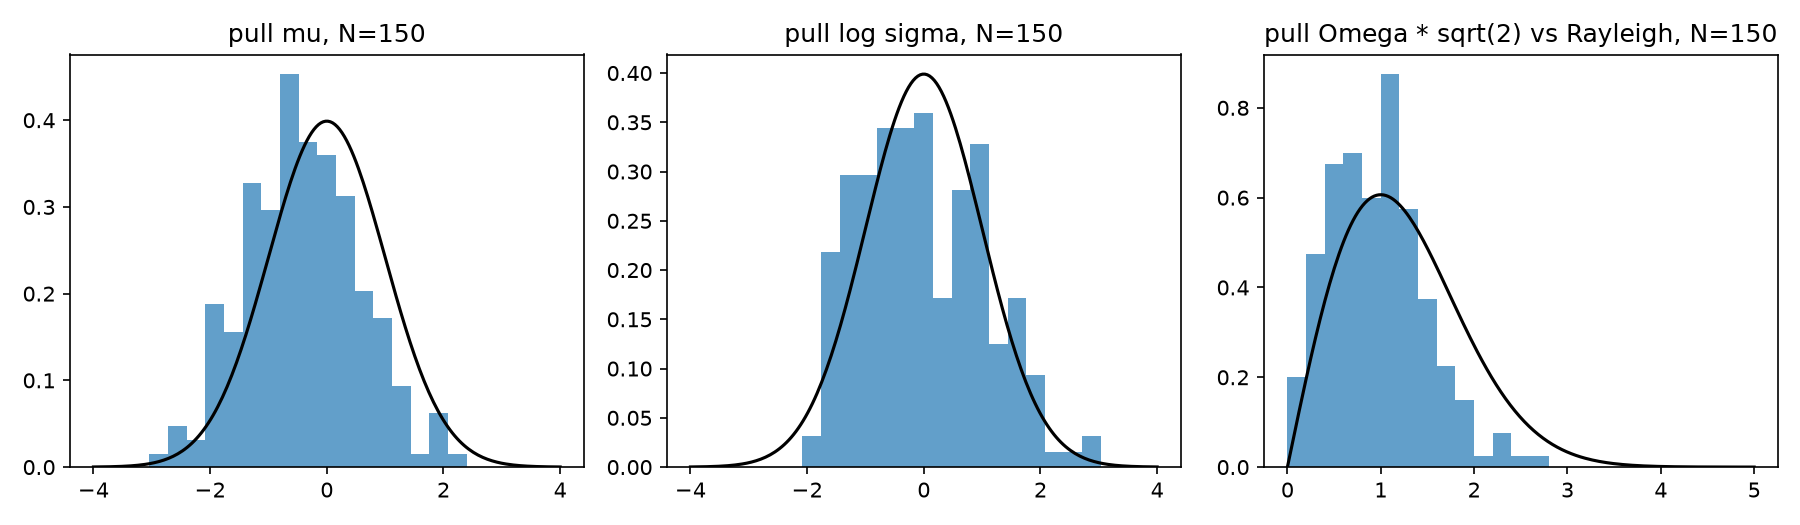

In [1]:
from pathlib import Path

from IPython.display import Image, display

OUT = Path("..") / "outputs"   # figure prodotte da scripts/caso_C_checklist.py
display(Image(OUT / "caso_C_pull.png"))

## 4. Coverage

Frazione di esperimenti in cui l'intervallo credibile contiene il valore vero. L'errore binomiale
al 68% vale ±0.03 (M = 200), ±0.05 (M = 100) e ±0.07 (M = 40).

| N | $\mu_E$ 68/90/95% | $\log\sigma_E$ 68/90/95% | $\Omega_n$ (HPD) 68/90/95% |
|---|---|---|---|
| 50 | 0.69 / 0.90 / 0.96 | 0.67 / 0.88 / 0.94 | 0.85 / 0.96 / 1.00 |
| 150 | 0.66 / 0.88 / 0.94 | 0.61 / 0.87 / 0.94 | 0.87 / 0.96 / 0.98 |
| 300 | 0.55 / 0.81 / 0.86 | 0.64 / 0.87 / 0.94 | 0.84 / 0.97 / 1.00 |
| 1000 | 0.48 / 0.70 / 0.72 | 0.72 / 0.95 / 0.98 | 0.85 / 0.98 / 0.98 |

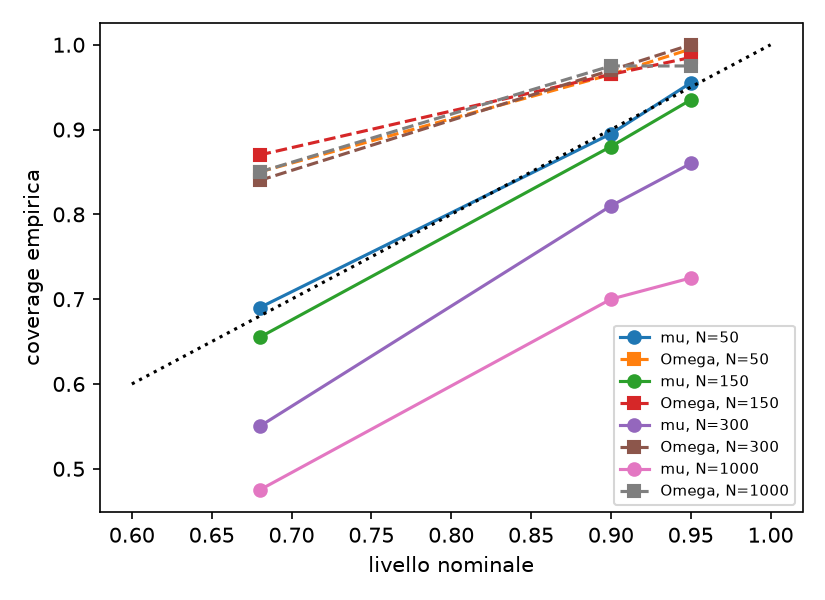

In [2]:
display(Image(OUT / "caso_C_coverage.png"))

* **$\log\sigma_E$**: la coverage è nominale entro gli errori binomiali.
* **$\Omega_n$**: la coverage è sopra il nominale, cioè le regioni sono conservative. È un
  errore nel verso sicuro. Nonostante lo stadio 2 usi $\hat\Omega_n$ come plug-in, l'incertezza
  sulla direzione non rovina gli intervalli degli iperparametri.
* **$\mu_E$**: la coverage è corretta a N ≤ 150 e **crolla** al crescere di N, fino al 48%
  invece del 68% a N = 1000. Anche questa è la conseguenza diretta del bias costante.

## 5. Contrazione

Pendenza log-log dell'rms dell'errore in funzione di N; $1/\sqrt N$ corrisponde a −0.5. Si
riporta anche rms·$\sqrt N$, che è costante se la contrazione è ideale.

| | pendenza | rms·$\sqrt N$ (N = 50, 150, 300, 1000) |
|---|---|---|
| $\Omega_n$ [rad] | −0.505 | 0.378, 0.371, 0.375, 0.371 |
| $\mu_E$ [MeV] | −0.360 | 0.577, 0.677, 0.772, 0.872 |
| $\log\sigma_E$ | −0.735 | 3.32, 3.15, 2.79, 1.64 |

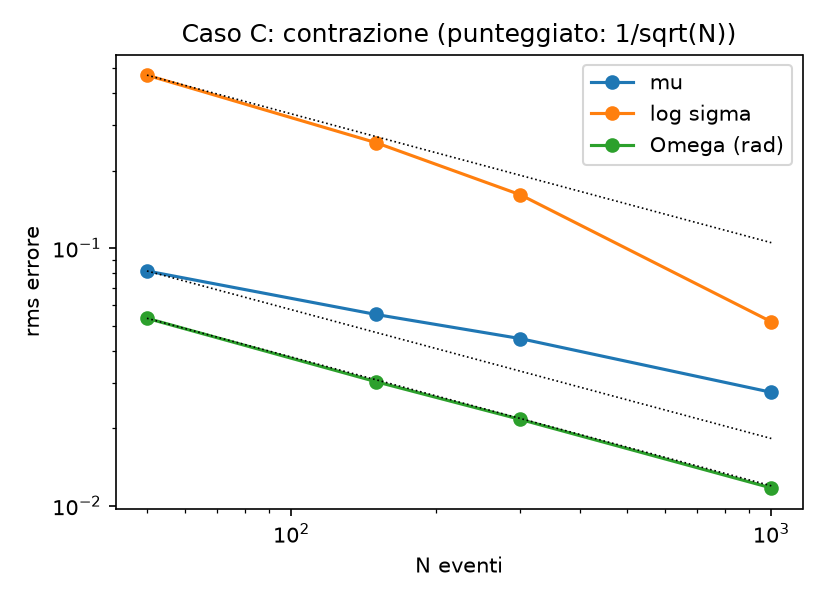

In [3]:
display(Image(OUT / "caso_C_contrazione.png"))

* **$\Omega_n$**: la contrazione è ideale.
* **$\log\sigma_E$**: la contrazione è più rapida di $1/\sqrt N$. A N piccolo lo scatter
  intrinseco dello spettro si distingue a fatica dall'effetto della cinematica: il posterior è
  largo e non gaussiano, e il regime asintotico arriva solo oltre qualche centinaio di eventi.
* **$\mu_E$**: la contrazione è più lenta di $1/\sqrt N$ e tende a un **plateau** vicino a
  0.02 MeV. Nella checklist di validazione un plateau è il segnale di un sistematico condiviso.
  Il notebook 02 mostra lo stesso comportamento con uno shift comune del 2% su $E_p$.

## 6. Robustezza al prior

A N = 150 si ripete lo stadio 2 sugli stessi dati con un prior uniforme in $\sigma_E$, invece che
uniforme in $\log\sigma_E$. Gli spostamenti sono espressi in unità di deviazione standard
posteriore:

| | spostamento medio | massimo spostamento assoluto |
|---|---|---|
| $\mu_E$ | −0.01 | 0.15 |
| $\log\sigma_E$ | +0.15 | 0.68 |

La coverage di $\log\sigma_E$ con il prior uniforme vale 0.59 / 0.89 / 0.95, compatibile con
quella del prior log-uniforme.

$\mu_E$ è insensibile al prior. $\sigma_E$ lo è moderatamente: a N = 150 cambiare prior sposta
la stima di una frazione della sua incertezza, al più di circa 0.7σ. Il limite superiore
`SIGMA_E_MAX` della griglia globale non entra nel risultato, perché la griglia fine è ristretta
alla finestra dove sta la massa del posterior.

## Esito

| parametro | calibrato? | commento |
|---|---|---|
| $\Omega_n$ | sì, conservativo | contrazione $1/\sqrt N$ ideale; incertezza dichiarata ~25% larga |
| $\sigma_E$ | sì | bias da prior a N piccolo che si annulla; pull e coverage nominali; moderata dipendenza dal prior a N = 150 |
| $\mu_E$ | **no, per N ≳ 300** | bias costante ≈ −0.02 MeV (≈ 0.6%) che non si media via |

La direzione e la larghezza dello spettro sono ricostruite correttamente. Il centroide
dell'energia ha un **sistematico condiviso** piccolo: è trascurabile finché l'errore statistico lo
domina (N ≲ 150), ma diventa dominante a statistica alta **(c)**.

Tutti gli esperimenti condividono il modello e non i dati, quindi la causa del bias va cercata in
un'approssimazione della verosimiglianza, non nella statistica. Candidati da testare **(d)**:

1. **Modello dell'errore angolare.** Il generatore sposta la traccia in 2D sul piano tangente,
   mentre la verosimiglianza tratta l'errore sull'angolo polare come una gaussiana 1D
   (approssimazione (b) del notebook 03). Per la direzione questo mismatch è innocuo, ma può
   spostare in modo sistematico la relazione $E_p = E_n\cos^2\theta$ usata per l'energia.
2. **Discretizzazione** della griglia locale in $\theta$ o della griglia in $E_n$ usata nella
   marginalizzazione gerarchica.
3. **Plug-in di $\hat\Omega_n$**: è improbabile, perché l'errore sulla direzione scende come
   $1/\sqrt N$ mentre il bias resta fisso.

Un test diretto consiste nel ripetere lo stadio 2 con $\Omega_n$ vero e dati generati con un
errore polare 1D, cioè lo stesso modello della verosimiglianza. Se il bias sparisce, la causa è il
punto 1.